# Figure 4: In Vivo-Specific Hits

Kexin Dong

Last update: June 2026

In [45]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from matplotlib_venn import venn2, venn3
import warnings
import os
warnings.filterwarnings('ignore')

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()
greys   = sns.color_palette('Greys').as_hex()
teals   = sns.color_palette('BuPu').as_hex()

BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'


In [46]:
dfs = {
    'ABE_OG':         pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
}

conds_focused = ['d15', 'bm', 'spleen']
conds_og      = ['d15', 'bm', 'spleen', 'men']

_ABE_SAMP_OG = {
    'bm':     ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
    'spleen': ['spleen1','spleen2','spleen3','spleen4'],
    'men':    ['meninges1','meninges2','meninges3','meninges4','meninges5'],
    'd15':    ['d15_rep1','d15_rep2','d15_rep3'],
}

_TISSUE_COLOR = {
    'd15':    '#756bb1',
    'spleen': '#74c476',
    'bm':     '#4393c3',
    'men':    '#fe9929',
}
_TISSUE_LABEL = {'d15': 'In Vitro (D15)', 'spleen': 'Spleen',
                 'bm': 'Bone Marrow', 'men': 'Meninges'}

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')


Loaded:
  ABE_OG: 1070 guides
  ABE_EPO_T0: 376 guides
  ABE_EPO_T0_FSR: 376 guides


## Part 1: In Vivo-Specific Hits — 3-Screen Venn (ABE only)

Collect in vivo-specific hits from GJ/JA T0, FSR T0, and OG screens (ABE only).
Criteria: FDR < 0.1 AND LFC ≥ 1 in at least one in vivo tissue; NOT a hit at d15.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


In vivo-specific ABE hits per screen:
  ABE_EPO_T0: 18 in vivo-specific guides
  ABE_EPO_T0_FSR: 13 in vivo-specific guides
  ABE_OG: 67 in vivo-specific guides


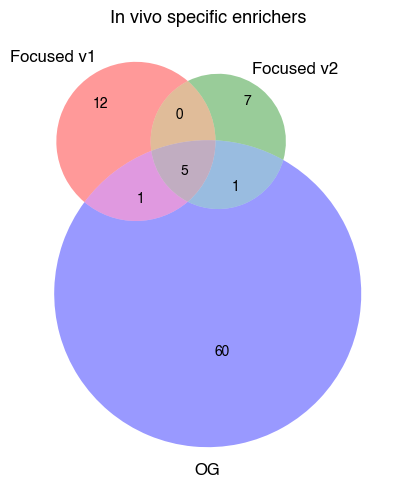


Triple overlap: 5 guides
['gRNA_4578', 'gRNA_5194', 'gRNA_7393', 'gRNA_8228', 'gRNA_8803']


In [47]:
def collect_invivo_abe(abe_key, conditions, fdr_method='fishers',
                       fdr_cutoff=0.1, effect='median', lfc_cutoff=1.0,
                       min_sensor=100, min_edit=20, min_input=2):
    targ = dfs[abe_key].copy()
    targ['Editor'] = 'ABE'
    targ = targ[targ['classification'] == 'targeting guide'].copy()
    in_conds = list(conditions)

    edit_cols   = [f'target_base_edit_perc_{c}' for c in in_conds
                   if f'target_base_edit_perc_{c}' in targ.columns]
    sensor_cols = [f'sensor_reads_{c}' for c in in_conds
                   if f'sensor_reads_{c}' in targ.columns]
    if edit_cols:
        targ = targ[(targ[edit_cols]   >= min_edit  ).any(axis=1)]
    if sensor_cols:
        targ = targ[(targ[sensor_cols] >= min_sensor).any(axis=1)]
    if 'Input_median' in targ.columns:
        targ = targ[targ['Input_median'] >= min_input]

    invivo_conds = [c for c in in_conds if c != 'd15']

    def lfc_col(c): return f'LFC_{effect}_{c}'
    def fdr_col(c): return f'FDR_{c}_{fdr_method}'
    def not_strong(c):
        lc, fc = lfc_col(c), fdr_col(c)
        if lc not in targ.columns or fc not in targ.columns:
            return pd.Series(True, index=targ.index)
        return ~((targ[fc] < fdr_cutoff) & (targ[lc] >= lfc_cutoff))

    mask_vivo = not_strong('d15')
    fdr_vivo  = pd.Series(False, index=targ.index)
    for c in invivo_conds:
        if fdr_col(c) in targ.columns:
            fdr_vivo |= ((targ[fdr_col(c)] < fdr_cutoff) & (targ[lfc_col(c)] > lfc_cutoff))
    mask_vivo &= fdr_vivo

    invivo_hits = targ[mask_vivo].copy()
    print(f'  {abe_key}: {len(invivo_hits)} in vivo-specific guides')
    return set(invivo_hits['gRNA_id']), invivo_hits


print('In vivo-specific ABE hits per screen:')
gjja_ids, gjja_df = collect_invivo_abe('ABE_EPO_T0',     conds_focused)
fsr_ids,  fsr_df  = collect_invivo_abe('ABE_EPO_T0_FSR', conds_focused)
og_ids,   og_df   = collect_invivo_abe('ABE_OG',         conds_og)

# ── 3-way Venn
screen_labels = ['Focused v1', 'Focused v2', 'OG']
sets = [gjja_ids, fsr_ids, og_ids]

fig, ax = plt.subplots(figsize=(6, 5))
venn3(sets, set_labels=screen_labels, ax=ax)
ax.set_title('In vivo specific enrichers', fontsize=13, fontweight='bold')
fig.tight_layout()
os.makedirs(BASE + 'figures/figure4', exist_ok=True)
fig.savefig(BASE + 'figures/figure4/venn_invivo_abe.pdf', bbox_inches='tight')
plt.show()

triple_overlap = gjja_ids & fsr_ids & og_ids
print(f'\nTriple overlap: {len(triple_overlap)} guides')
print(sorted(triple_overlap))


## Part 2: Triple Overlap Hits — OG Screen Barplot

For each of the 5 triple-overlap guides, show LFC across tissues in the OG screen
(spleen, bone marrow, meninges, d15) as boxplot + stripplot.

Plotting 5 guides across OG screen tissues
Tissue        bm  d15  spleen
Mutation                     
Foxa1 Y259C    5    3       4
Idh2 R172G     5    3       4
Mtor Y1974H    5    3       4
Nsd1 T2030A    5    3       4
Pik3ca C378R   5    3       4


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


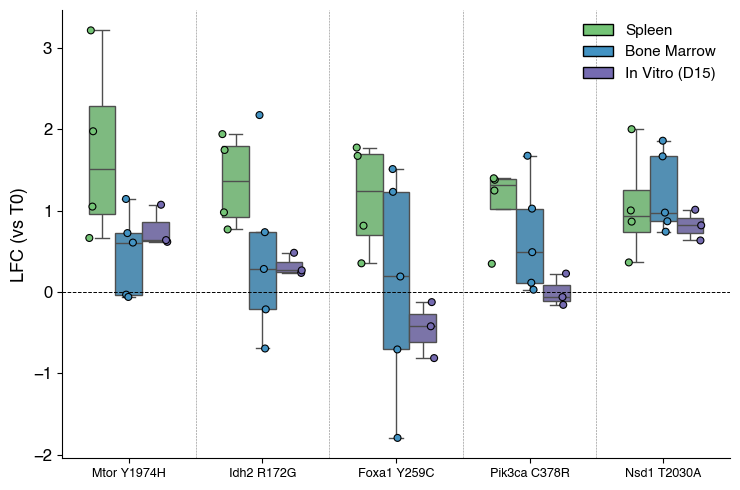

In [48]:
# ── Build long-format data from OG screen for triple-overlap guides
og_df_full = dfs['ABE_OG'].copy()
plot_tissues_og = ('spleen', 'bm', 'd15')
tissue_col_map  = {
    'spleen': _ABE_SAMP_OG['spleen'],
    'bm':     _ABE_SAMP_OG['bm'],
    'd15':    _ABE_SAMP_OG['d15'],
}

records = []
for gid in sorted(triple_overlap):
    row = og_df_full[og_df_full['gRNA_id'] == gid]
    if row.empty:
        print(f'  {gid} not found in ABE_OG — skipping')
        continue
    row = row.iloc[0]

    # build label
    mg = str(row.get('gene_name_m_corrected', row.get('Gene', gid)))
    mv = str(row.get('HGVSp_m', ''))
    hv = str(row.get('HGVSp_h', ''))
    if hv.startswith('p.'): hv = hv[2:]
    if mv in ('Not calculated (legacy)', 'nan', ''): mv = hv
    label = f'{mg} {mv}'.strip()

    for tissue, cols in tissue_col_map.items():
        for col in cols:
            if col in row.index and pd.notna(row[col]):
                records.append({'gRNA_id': gid, 'Mutation': label,
                                'Tissue': tissue, 'LFC': row[col]})

plot_df = pd.DataFrame(records)
print(f'Plotting {plot_df["gRNA_id"].nunique()} guides across OG screen tissues')
print(plot_df.groupby(['Mutation','Tissue']).size().unstack(fill_value=0))

# ── Plot: one multi-guide figure, tissue-coloured boxes
guide_order = (plot_df.groupby('Mutation')['LFC']
               .apply(lambda x: x[plot_df.loc[x.index,'Tissue']=='spleen'].mean())
               .sort_values(ascending=False).index.tolist())

palette = [_TISSUE_COLOR[t] for t in plot_tissues_og]

fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(guide_order)), 5))
sns.boxplot(data=plot_df, x='Mutation', y='LFC', hue='Tissue',
            ax=ax, order=guide_order,
            palette=palette, hue_order=list(plot_tissues_og),
            showfliers=False, legend=False, width=0.6, linewidth=1)
sns.stripplot(data=plot_df, x='Mutation', y='LFC', hue='Tissue',
              ax=ax, order=guide_order,
              palette=palette, hue_order=list(plot_tissues_og),
              dodge=True, edgecolor='black', linewidth=0.8, size=5, legend=False)

ax.axhline(0, linestyle='--', color='black', linewidth=0.7)
for k in range(len(guide_order) - 1):
    ax.axvline(k + 0.5, linestyle='--', color='black', linewidth=0.4, alpha=0.5)

handles = [Patch(facecolor=_TISSUE_COLOR[t], edgecolor='black', label=_TISSUE_LABEL[t])
           for t in plot_tissues_og]
ax.legend(handles=handles, frameon=False, fontsize=11, loc='upper right')
ax.set_xlabel('')
ax.set_ylabel('LFC (vs T0)', fontsize=13)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(BASE + 'figures/figure4/triple_invivo_og_barplot.pdf', bbox_inches='tight')
plt.show()


## Part 3: Validation Experiment

Validation data for the 5 triple-overlap in vivo-specific enrichers.
Screen LFC (individual replicates) overlaid with validation LFC (Final vs Initial BFP%).
One figure per tissue: Spleen, Bone Marrow, In Vitro.

In [49]:
# ── Load and process validation data (REAL data) ─────────────────────────────
VAL_FILE = BASE + 'validation/invivo_specific_abe_validation_data.xlsx'
validation_raw = pd.read_excel(VAL_FILE)

# NT carries gRNA_id gRNA_14799 (non-targeting control; not in the screen
# library, so it stays out of the correlation / per-tissue barplots).
validation_raw.loc[validation_raw['sgRNA'] == 'ABE_NT', 'gRNA_id'] = 'gRNA_14799'

# Real mutation labels for every validation guide (keyed by sgRNA in the file).
# Guides WITH a library gRNA_id are the in-vivo-specific enrichers that were in
# the original screen; the rest are extra validation-only guides.
VAL_LABELS = {
    'ABE_FOXA1':         'Foxa1 Y259C',
    'ABE_IDH2':          'Idh2 R172G',
    'ABE_MTOR':          'Mtor Y1974H',
    'ABE_NSD1':          'Nsd1 T2030A',
    'ABE_PIK3CA':        'Pik3ca C378R',
    'ABE_BCRABL_1817':   'ABL (NAR BCRABL_1817)',
    'ABE_BCRABL_1873':   'ABL (NAR BCRABL_1873)',
    'ABE_Pol2rb_splice': 'Pol2rb splice',
    'ABE_SMAD4':         'Smad4 K507E',
    'ABE_PHF6':          'Phf6 H302R',
    'ABE_NT':            'NT',
}

def _compute_val_lfc(df):
    """Drop blank wells, use provided Log2FC, recompute any missing Final value."""
    df = df.dropna(subset=['Percent_population']).reset_index(drop=True)
    df = df.rename(columns={'Log2 fold change': 'LFC'})
    out = []
    for sgr in df['sgRNA'].unique():
        init_pct = df[(df['sgRNA'] == sgr) &
                      (df['Timepoint'] == 'Initial')]['Percent_population'].values[0]
        sub = df[df['sgRNA'] == sgr].copy()
        sub['LFC'] = sub['LFC'].fillna(np.log2(sub['Percent_population'] / init_pct))
        out.append(sub)
    res = pd.concat(out).reset_index(drop=True)
    res['Name'] = res['sgRNA'].map(VAL_LABELS).fillna(res['sgRNA'])
    return res

# ALL 11 guides (incl. controls / library-absent extras) — for the overview plot.
validation_all = _compute_val_lfc(validation_raw.copy())

# Only the 5 enrichers present in the screen library — for the quantitative
# screen-vs-validation comparison (correlation + per-tissue barplots).
validation = validation_raw[validation_raw['gRNA_id'].isin(triple_overlap)].copy()
validation_lfc = _compute_val_lfc(validation)

# Annotation from ABE_OG (library guides only)
og_info = dfs['ABE_OG'][['gRNA_id','Gene','gene_name_h','HGVSp_h','HGVSp_m','gene_name_m_corrected']].copy()
validation_merged = pd.merge(validation_lfc, og_info, on='gRNA_id')

# ── Build screen long-format data (OG screen, ABE only) ──────────────────────
_ABE_SAMP_OG_VAL = {
    'Spleen':      ['spleen1','spleen2','spleen3','spleen4'],
    'Bone Marrow': ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
    'In Vitro':    ['d15_rep1','d15_rep2','d15_rep3'],
}
og_screen = dfs['ABE_OG'].copy()

screen_records = []
for gid in sorted(triple_overlap):
    row = og_screen[og_screen['gRNA_id'] == gid]
    if row.empty: continue
    row = row.iloc[0]
    for tissue, cols in _ABE_SAMP_OG_VAL.items():
        for col in cols:
            if col in row.index and pd.notna(row[col]):
                screen_records.append({'gRNA_id': gid, 'LFC': row[col], 'Tissue': tissue})

screen_long = pd.DataFrame(screen_records)
screen_long['Condition'] = 'Screen'

# Final validation rows only
val_final = validation_merged[validation_merged['Timepoint'] == 'Final'].copy()
val_final['Condition'] = 'Validation'

# Combined — keep only needed cols
combined = pd.concat([
    screen_long[['gRNA_id','LFC','Tissue','Condition']],
    val_final[['gRNA_id','LFC','Tissue','Condition']],
], ignore_index=True)

# Guide order: sorted by OG spleen LFC median descending
g_order = (og_screen[og_screen['gRNA_id'].isin(triple_overlap)]
           .sort_values('LFC_median_spleen', ascending=False)['gRNA_id'].tolist())

# Readable x-tick labels (use the curated mutation labels)
_SGR_BY_GID = validation[['gRNA_id','sgRNA']].drop_duplicates().set_index('gRNA_id')['sgRNA'].to_dict()
name_map = {gid: VAL_LABELS.get(_SGR_BY_GID.get(gid, ''), gid) for gid in g_order}
xticklabels = [name_map[g] for g in g_order]

# Initial BFP % for theoretical max LFC lines
init_pct_map = (validation_merged[validation_merged['Timepoint']=='Initial']
                .drop_duplicates('gRNA_id').set_index('gRNA_id')['Percent_population'].to_dict())

# Sanity: quantitative plots must use only the 5 library enrichers
assert set(combined['gRNA_id'].dropna()) <= triple_overlap

print(f'Library enrichers (in correlation/barplots): {len(g_order)} -> {[name_map[g] for g in g_order]}')
print(f'All validation guides (overview only): {validation_all["sgRNA"].nunique()}')
print('Library-absent extras:', sorted(set(validation_all["sgRNA"]) - set(_SGR_BY_GID.values())))

Library enrichers (in correlation/barplots): 5 -> ['Mtor Y1974H', 'Idh2 R172G', 'Pik3ca C378R', 'Foxa1 Y259C', 'Nsd1 T2030A']
All validation guides (overview only): 11
Library-absent extras: ['ABE_BCRABL_1817', 'ABE_BCRABL_1873', 'ABE_NT', 'ABE_PHF6', 'ABE_Pol2rb_splice', 'ABE_SMAD4']


### Figure 5b: Screen vs Validation LFC correlation (ABE only)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


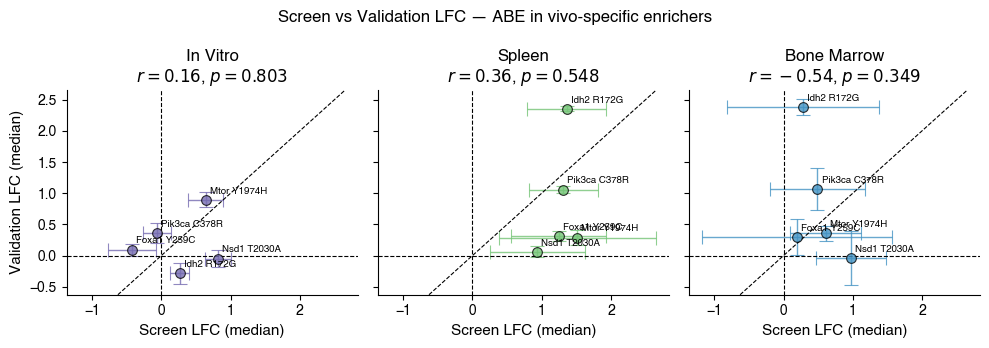

In [50]:
# ── Build screen median + std per guide per tissue ────────────────────────────
og_screen = dfs['ABE_OG'].copy()
guides_val = sorted(triple_overlap)

sp_cols  = ['spleen1','spleen2','spleen3','spleen4']
bm_cols  = ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5']
iv_cols  = ['d15_rep1','d15_rep2','d15_rep3']

screen_med = og_screen[og_screen['gRNA_id'].isin(guides_val)][
    ['gRNA_id','LFC_median_spleen','LFC_median_bm','LFC_median_d15']
].copy()

for col_key, cols in [('sp_std', sp_cols), ('bm_std', bm_cols), ('iv_std', iv_cols)]:
    screen_med[col_key] = (
        og_screen[og_screen['gRNA_id'].isin(guides_val)][cols]
        .std(axis=1).values
    )

# ── Build validation median + std per guide per tissue ───────────────────────
val_agg = (
    validation_merged[validation_merged['Timepoint'] == 'Final']
    .groupby(['gRNA_id', 'Tissue'])['LFC']
    .agg(median='median', std='std')
    .reset_index()
)
val_pivot = val_agg.pivot(index='gRNA_id', columns='Tissue', values=['median','std']).reset_index()
val_pivot.columns = ['gRNA_id'] + [f'{stat}_{t}' for stat, t in val_pivot.columns[1:]]

m1 = pd.merge(screen_med, val_pivot, on='gRNA_id')

# ── Correlation scatter with error bars (3 tissues, ABE only) ─────────────────
tissues_corr = [
    ('d15',    'LFC_median_d15',    'iv_std',   'median_In Vitro',   'std_In Vitro',   'In Vitro',   '#756bb1'),
    ('spleen', 'LFC_median_spleen', 'sp_std',   'median_Spleen',     'std_Spleen',     'Spleen',     '#74c476'),
    ('bm',     'LFC_median_bm',     'bm_std',   'median_Bone Marrow','std_Bone Marrow','Bone Marrow','#4393c3'),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharex=True, sharey=True)

for ax, (_, x_col, xerr_col, y_col, yerr_col, title, color) in zip(axes, tissues_corr):
    ax.errorbar(
        m1[x_col], m1[y_col],
        xerr=m1[xerr_col], yerr=m1[yerr_col].fillna(0),
        fmt='o', color=color, capsize=5, alpha=0.8,
        elinewidth=1, markersize=7, markeredgecolor='black', markeredgewidth=0.8,
    )
    # label each point
    for _, row in m1.iterrows():
        lab = name_map.get(row['gRNA_id'], row['gRNA_id'])
        ax.annotate(lab, (row[x_col], row[y_col]),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

    ax.axhline(0, color='black', linestyle='dashed', linewidth=0.8)
    ax.axvline(0, color='black', linestyle='dashed', linewidth=0.8)
    ax.axline((0, 0), slope=1, color='black', linestyle='dashed', linewidth=0.8)

    # Per-tissue Pearson r
    sub = m1[[x_col, y_col]].dropna()
    if len(sub) >= 2:
        r_t, p_t = scipy.stats.pearsonr(sub[x_col], sub[y_col])
        ax.set_title(f'{title}\n$r={r_t:.2f}$, $p={p_t:.3f}$', fontsize=12)
    else:
        ax.set_title(title, fontsize=13)
    ax.set_xlabel('Screen LFC (median)', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Validation LFC (median)', fontsize=11)

fig.suptitle('Screen vs Validation LFC — ABE in vivo-specific enrichers',
             fontsize=12, fontweight='bold')

fig.tight_layout()
os.makedirs(BASE + 'figures/figure4', exist_ok=True)
fig.savefig(BASE + 'figures/figure4/validation_correlation.pdf', bbox_inches='tight')
plt.show()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


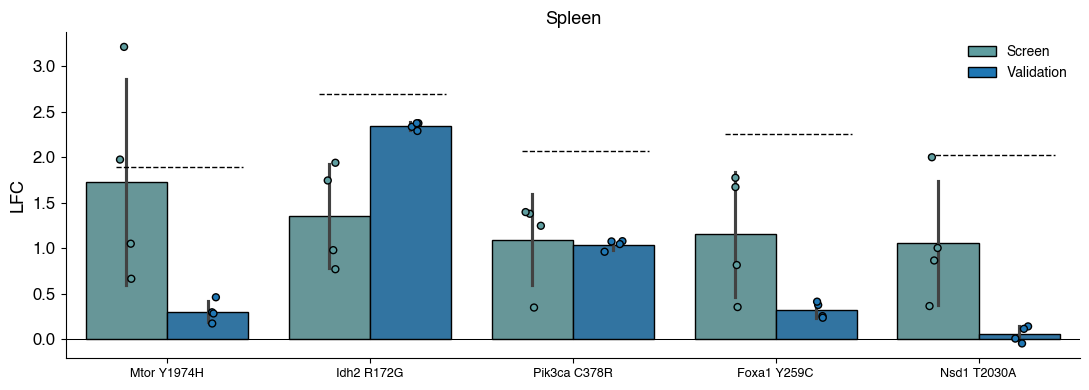

In [51]:
def plot_validation_tissue(tissue, palette, savename):
    """Figure-5b style: barplot + stripplot of screen vs validation LFC for one tissue."""
    n_guides = len(g_order)
    data = combined[combined['Tissue'] == tissue].copy()

    fig, ax = plt.subplots(figsize=(2.2 * n_guides, 4), sharey=False)

    sns.barplot(data=data, x='gRNA_id', y='LFC', hue='Condition',
                errorbar='sd', order=g_order, palette=palette,
                edgecolor='black', linewidth=1, ax=ax, legend=False)
    sns.stripplot(data=data, x='gRNA_id', y='LFC', hue='Condition',
                  dodge=True, order=g_order, palette=palette,
                  edgecolor='black', linewidth=1, ax=ax, legend=False)

    ax.axhline(0, color='black', linewidth=0.75)

    # Theoretical max LFC dashed lines per guide
    for i, gid in enumerate(g_order):
        init = init_pct_map.get(gid, None)
        if init is not None and init > 0:
            max_lfc = np.log2(100 / init)
            xmin = i / n_guides + 1 / (n_guides * 4)
            xmax = (i + 1) / n_guides - 1 / (n_guides * 8)
            ax.axhline(max_lfc, xmin=xmin, xmax=xmax,
                       color='black', linestyle='dashed', linewidth=1)

    ax.set_xticklabels(xticklabels, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('LFC', fontsize=13)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_title(tissue, fontsize=13, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

    # Legend
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=palette[0], edgecolor='black', label='Screen'),
               Patch(facecolor=palette[1], edgecolor='black', label='Validation')]
    ax.legend(handles=handles, frameon=False, fontsize=10, loc='upper right')

    fig.tight_layout()
    os.makedirs(BASE + 'figures/figure4', exist_ok=True)
    fig.savefig(BASE + f'figures/figure4/{savename}', bbox_inches='tight')
    plt.show()


pal_spleen = ['cadetblue',  'tab:blue']
pal_bm     = ['slateblue',  'indigo']
pal_iv     = ['lightgrey',  'tab:grey']

plot_validation_tissue('Spleen',      pal_spleen, 'validation_spleen.pdf')


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


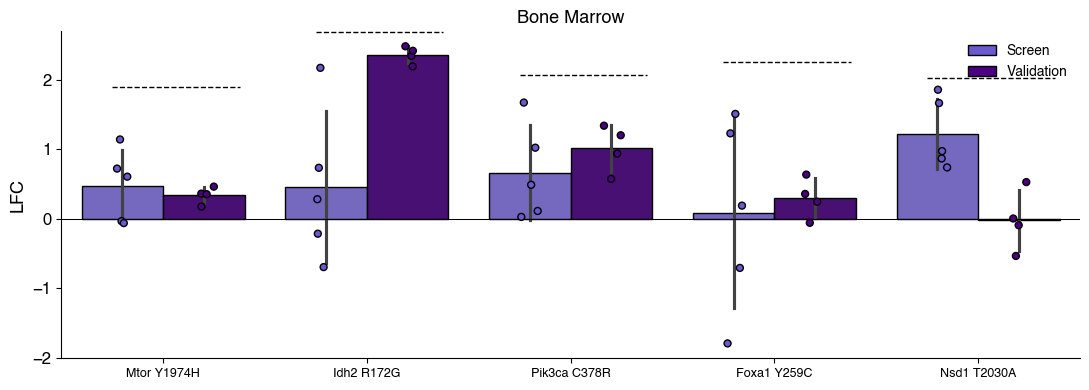

In [52]:
plot_validation_tissue('Bone Marrow', pal_bm,     'validation_bm.pdf')


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


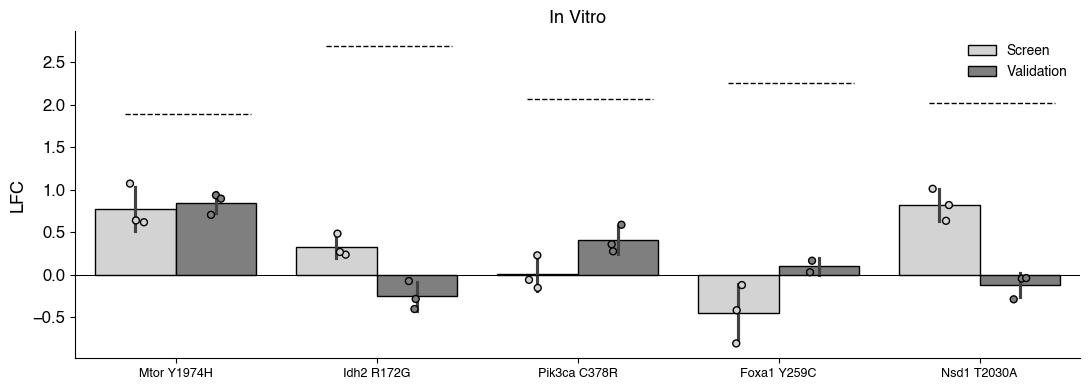

In [53]:
plot_validation_tissue('In Vitro',    pal_iv,     'validation_invitro.pdf')


### Overview: validation LFC across all guides

All ABE validation guides — the 5 in-vivo-specific enrichers (present in the
screen library) plus extra validation-only guides not in the library: known
positive controls (BCR-ABL, Pol2rb splice), additional candidate oncogenic
mutations (Smad4 K507E, Phf6 H302R), and a non-targeting (NT) negative control.
Validation LFC (Final vs Initial BFP%) per tissue.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


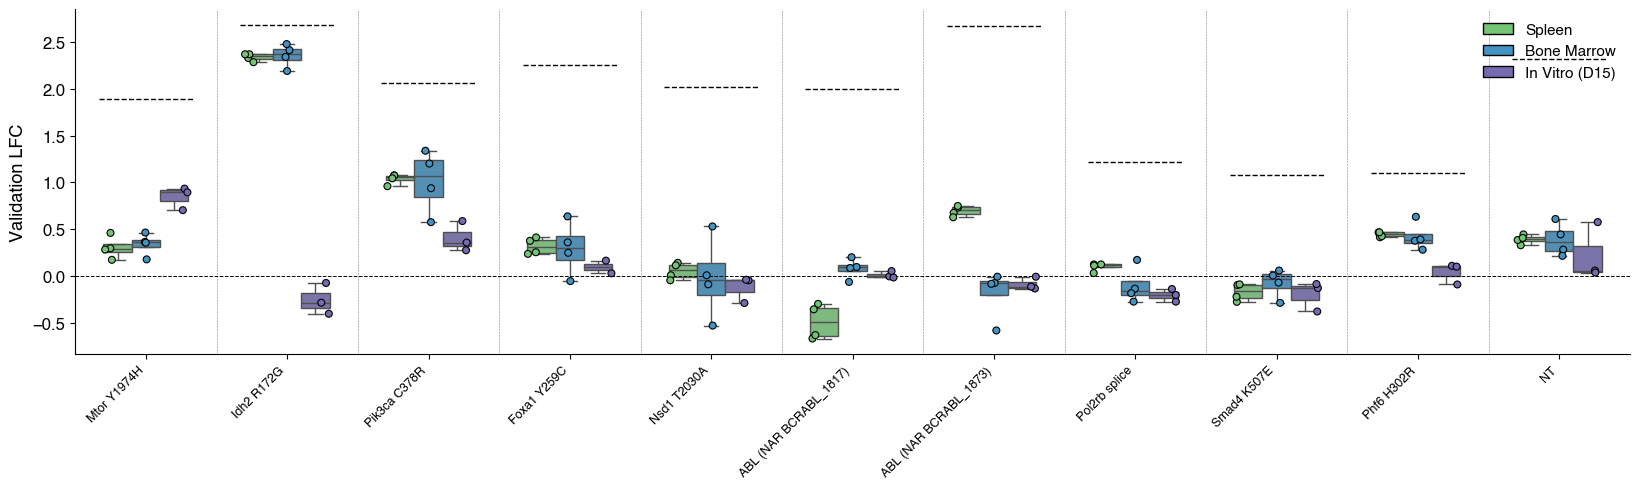

In [54]:
# ── Overview: validation LFC for ALL guides (Part-2 box+strip style) ──────────
val_all_final = validation_all[validation_all['Timepoint'] == 'Final'].copy()
val_all_final['Mutation'] = val_all_final['sgRNA'].map(VAL_LABELS)

# Order: 5 library enrichers (screen order), then extras, NT last.
LIB_SGR     = [_SGR_BY_GID[g] for g in g_order]                   # 5 enrichers
extras      = [s for s in VAL_LABELS if s not in LIB_SGR and s != 'ABE_NT']
sgr_order   = LIB_SGR + extras + ['ABE_NT']
guide_order = [VAL_LABELS[s] for s in sgr_order]                 # x-axis = mutation label

plot_tissues   = ('spleen', 'bm', 'd15')
_T_FROM_TISSUE = {'Spleen': 'spleen', 'Bone Marrow': 'bm', 'In Vitro': 'd15'}
val_all_final['T'] = val_all_final['Tissue'].map(_T_FROM_TISSUE)

palette = [_TISSUE_COLOR[t] for t in plot_tissues]

fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(guide_order)), 5))
sns.boxplot(data=val_all_final, x='Mutation', y='LFC', hue='T',
            ax=ax, order=guide_order,
            palette=palette, hue_order=list(plot_tissues),
            showfliers=False, legend=False, width=0.6, linewidth=1)
sns.stripplot(data=val_all_final, x='Mutation', y='LFC', hue='T',
              ax=ax, order=guide_order,
              palette=palette, hue_order=list(plot_tissues),
              dodge=True, edgecolor='black', linewidth=0.8, size=5, legend=False)

ax.axhline(0, linestyle='--', color='black', linewidth=0.7)
for k in range(len(guide_order) - 1):
    ax.axvline(k + 0.5, linestyle='--', color='black', linewidth=0.4, alpha=0.5)

# Theoretical max LFC dashed line per guide (Initial BFP% is tissue-independent).
val_init = (validation_all[validation_all['Timepoint'] == 'Initial']
            .drop_duplicates('sgRNA').set_index('sgRNA')['Percent_population'].to_dict())
n_g = len(guide_order)
for i, sgr in enumerate(sgr_order):
    init = val_init.get(sgr)
    if init is not None and init > 0:
        max_lfc = np.log2(100 / init)
        ax.axhline(max_lfc, xmin=i / n_g + 1 / (n_g * 6), xmax=(i + 1) / n_g - 1 / (n_g * 6),
                   color='black', linestyle='dashed', linewidth=1)

handles = [Patch(facecolor=_TISSUE_COLOR[t], edgecolor='black', label=_TISSUE_LABEL[t])
           for t in plot_tissues]
ax.legend(handles=handles, frameon=False, fontsize=11, loc='upper right')
ax.set_xlabel('')
ax.set_ylabel('Validation LFC', fontsize=13)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('', fontsize=13, fontweight='bold')
fig.tight_layout()
os.makedirs(BASE + 'figures/figure4', exist_ok=True)
fig.savefig(BASE + 'figures/figure4/validation_all_guides.pdf', bbox_inches='tight')
plt.show()